In [1]:
import os

base = '/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate'

# Xem cấu trúc thư mục
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # chỉ xem 2 cấp đầu
        for f in files[:3]:
            print(f'{indent}  {f}')

character-dataset-for-vietnam-license-plate/
  Character dataset/
    N/
    7/
    2/
    B/
    F/
    H/
    5/
    E/
    Noise/
    U/
    M/
    8/
    X/
    0/
    K/
    Y/
    S/
    G/
    A/
    T/
    V/
    Z/
    3/
    1/
    C/
    4/
    P/
    9/
    L/
    6/
    D/


In [2]:
import os
import shutil
import cv2

base_src = '/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset'
output   = '/kaggle/working/char_cls'  # thư mục mới, đúng format

classes = sorted([c for c in os.listdir(base_src) if c != 'Noise'])

# Augmentation
from sklearn.model_selection import train_test_split
import albumentations as A
import numpy as np

aug = A.Compose([
    A.Rotate(limit=10, p=0.5),
    A.GaussNoise(p=0.4),
    A.RandomBrightnessContrast(p=0.5),
    A.Blur(blur_limit=2, p=0.3),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
])

TARGET = 200

for cls in classes:
    # Tạo thư mục đúng format ImageFolder
    os.makedirs(f'{output}/train/{cls}', exist_ok=True)
    os.makedirs(f'{output}/val/{cls}',   exist_ok=True)
    
    imgs = [f for f in os.listdir(f'{base_src}/{cls}')
            if f.lower().endswith(('.jpg','.png','.jpeg'))]
    
    train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)
    
    # Val: copy gốc
    for fname in val_imgs:
        shutil.copy(f'{base_src}/{cls}/{fname}',
                    f'{output}/val/{cls}/{fname}')
    
    # Train: copy gốc + augment
    for fname in train_imgs:
        shutil.copy(f'{base_src}/{cls}/{fname}',
                    f'{output}/train/{cls}/{fname}')
    
    needed = TARGET - len(train_imgs)
    for i in range(needed):
        fname = train_imgs[i % len(train_imgs)]
        img   = cv2.imread(f'{base_src}/{cls}/{fname}')
        img   = aug(image=img)['image']
        cv2.imwrite(f'{output}/train/{cls}/aug_{i}_{fname}', img)
    
    print(f"  {cls}: {len(train_imgs)} gốc + {max(0,needed)} aug "
          f"= {max(len(train_imgs), TARGET)} train | {len(val_imgs)} val")

print(f"\n✅ Xong! Cấu trúc:")
print(f"  train: {sum(len(os.listdir(f'{output}/train/{c}')) for c in classes)} ảnh")
print(f"  val:   {sum(len(os.listdir(f'{output}/val/{c}')) for c in classes)} ảnh")

/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:231: UserWarning: blur_limit: Invalid kernel size range (3, 2). Values less than 3 are not allowed. Range automatically adjusted to (3, 3).
  result = _ensure_min_value(result, min_value, info.field_name)


  0: 66 gốc + 134 aug = 200 train | 17 val
  1: 49 gốc + 151 aug = 200 train | 13 val
  2: 53 gốc + 147 aug = 200 train | 14 val
  3: 56 gốc + 144 aug = 200 train | 15 val
  4: 32 gốc + 168 aug = 200 train | 9 val
  5: 45 gốc + 155 aug = 200 train | 12 val
  6: 40 gốc + 160 aug = 200 train | 11 val
  7: 58 gốc + 142 aug = 200 train | 15 val
  8: 37 gốc + 163 aug = 200 train | 10 val
  9: 56 gốc + 144 aug = 200 train | 15 val
  A: 40 gốc + 160 aug = 200 train | 11 val
  B: 39 gốc + 161 aug = 200 train | 10 val
  C: 42 gốc + 158 aug = 200 train | 11 val
  D: 33 gốc + 167 aug = 200 train | 9 val
  E: 39 gốc + 161 aug = 200 train | 10 val
  F: 118 gốc + 82 aug = 200 train | 30 val
  G: 68 gốc + 132 aug = 200 train | 17 val
  H: 52 gốc + 148 aug = 200 train | 13 val
  K: 38 gốc + 162 aug = 200 train | 10 val
  L: 40 gốc + 160 aug = 200 train | 11 val
  M: 3 gốc + 197 aug = 200 train | 1 val
  N: 32 gốc + 168 aug = 200 train | 9 val
  P: 56 gốc + 144 aug = 200 train | 14 val
  S: 40 gốc + 16

In [3]:
import os
import shutil
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import albumentations as A

# Cài albumentations nếu chưa có
# !pip install albumentations -q

base = '/kaggle/input/datasets/nguyenquanglinh0109/character-dataset-for-vietnam-license-plate/Character dataset'
output = '/kaggle/working/char_dataset'

for split in ['train', 'val']:
    os.makedirs(f'{output}/images/{split}', exist_ok=True)
    os.makedirs(f'{output}/labels/{split}', exist_ok=True)

classes = sorted([c for c in os.listdir(base) if c != 'Noise'])
class_to_idx = {c: i for i, c in enumerate(classes)}

# Augmentation pipeline
aug = A.Compose([
    A.Rotate(limit=10, p=0.5),
    A.GaussNoise(p=0.4),
    A.RandomBrightnessContrast(p=0.5),
    A.Blur(blur_limit=2, p=0.3),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.Sharpen(p=0.3),
])

TARGET_PER_CLASS = 200  # augment để mỗi class có ít nhất 200 ảnh

total_train = 0
total_val = 0

for cls in classes:
    cls_dir = f'{base}/{cls}'
    images = [f for f in os.listdir(cls_dir) 
              if f.lower().endswith(('.jpg','.png','.jpeg'))]
    
    # Train/val split trước khi augment
    train_imgs, val_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )
    
    # ── VAL: copy gốc, không augment ──
    for fname in val_imgs:
        img = cv2.imread(f'{cls_dir}/{fname}')
        name = f'{cls}_{fname}'
        cv2.imwrite(f'{output}/images/val/{name}', img)
        label = name.rsplit('.', 1)[0] + '.txt'
        with open(f'{output}/labels/val/{label}', 'w') as f:
            f.write(f'{class_to_idx[cls]} 0.5 0.5 1.0 1.0\n')
    total_val += len(val_imgs)
    
    # ── TRAIN: augment đến TARGET_PER_CLASS ──
    # Copy ảnh gốc trước
    for fname in train_imgs:
        img = cv2.imread(f'{cls_dir}/{fname}')
        name = f'{cls}_{fname}'
        cv2.imwrite(f'{output}/images/train/{name}', img)
        label = name.rsplit('.', 1)[0] + '.txt'
        with open(f'{output}/labels/train/{label}', 'w') as f:
            f.write(f'{class_to_idx[cls]} 0.5 0.5 1.0 1.0\n')
    
    # Augment thêm nếu thiếu
    needed = TARGET_PER_CLASS - len(train_imgs)
    if needed > 0:
        aug_count = 0
        while aug_count < needed:
            fname = train_imgs[aug_count % len(train_imgs)]
            img = cv2.imread(f'{cls_dir}/{fname}')
            augmented = aug(image=img)['image']
            
            name = f'{cls}_aug{aug_count}.jpg'
            cv2.imwrite(f'{output}/images/train/{name}', augmented)
            label = name.rsplit('.', 1)[0] + '.txt'
            with open(f'{output}/labels/train/{label}', 'w') as f:
                f.write(f'{class_to_idx[cls]} 0.5 0.5 1.0 1.0\n')
            aug_count += 1
    
    total_train += max(len(train_imgs), TARGET_PER_CLASS)
    print(f"  {cls}: {len(train_imgs)} gốc → {max(len(train_imgs), TARGET_PER_CLASS)} train")

print(f"\n✅ Xong!")
print(f"Train: ~{total_train} ảnh")
print(f"Val:   {total_val} ảnh")

  0: 66 gốc → 200 train
  1: 49 gốc → 200 train
  2: 53 gốc → 200 train
  3: 56 gốc → 200 train
  4: 32 gốc → 200 train
  5: 45 gốc → 200 train
  6: 40 gốc → 200 train
  7: 58 gốc → 200 train
  8: 37 gốc → 200 train
  9: 56 gốc → 200 train
  A: 40 gốc → 200 train
  B: 39 gốc → 200 train
  C: 42 gốc → 200 train
  D: 33 gốc → 200 train
  E: 39 gốc → 200 train
  F: 118 gốc → 200 train
  G: 68 gốc → 200 train
  H: 52 gốc → 200 train
  K: 38 gốc → 200 train
  L: 40 gốc → 200 train
  M: 3 gốc → 200 train
  N: 32 gốc → 200 train
  P: 56 gốc → 200 train
  S: 40 gốc → 200 train
  T: 45 gốc → 200 train
  U: 44 gốc → 200 train
  V: 35 gốc → 200 train
  X: 62 gốc → 200 train
  Y: 15 gốc → 200 train
  Z: 25 gốc → 200 train

✅ Xong!
Train: ~6000 ảnh
Val:   357 ảnh


In [4]:
import os

base = '/kaggle/working/char_dataset'
print("Cấu trúc thư mục:")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  ({len(files)} files)')

Cấu trúc thư mục:
char_dataset/
  labels/
    train/
      (6000 files)
    val/
      (357 files)
  images/
    train/
      (6000 files)
    val/
      (357 files)


In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ── 1. Config ──────────────────────────────────────────────────────────
BASE   = '/kaggle/working/char_cls'
EPOCHS = 100
BATCH  = 128
LR     = 1e-3
IMGSZ  = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


Device : cuda
GPU    : Tesla T4


In [6]:
# ── 2. Transforms ──────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMGSZ, IMGSZ)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_tf = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMGSZ, IMGSZ)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


In [7]:
# ── 3. Dataset & DataLoader ────────────────────────────────────────────
train_ds = datasets.ImageFolder(f'{BASE}/train', transform=train_tf)
val_ds   = datasets.ImageFolder(f'{BASE}/val',   transform=val_tf)

train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

classes = train_ds.classes
NC      = len(classes)
print(f"\nClasses ({NC}): {classes}")
print(f"Train  : {len(train_ds)} ảnh")
print(f"Val    : {len(val_ds)} ảnh")


Classes (30): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z']
Train  : 6000 ảnh
Val    : 357 ảnh


In [8]:
# ── 4. Model ───────────────────────────────────────────────────────────
class CharCNN(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 64→32
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 2: 32→16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 3: 16→8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CharCNN(num_classes=NC).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel params: {total_params:,}")


Model params: 4,621,182


In [9]:
# ── 5. Loss / Optimizer / Scheduler ───────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ── 6. Train loop ──────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc = 0.0

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            preds = model(imgs)
            loss  = criterion(preds, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(imgs)
            correct    += (preds.argmax(1) == labels).sum().item()
            total      += len(imgs)

    return total_loss / total, correct / total

print("\nBắt đầu train...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'classes'    : classes,
            'val_acc'    : val_acc,
        }, '/kaggle/working/best_char_cnn.pth')

    # Log mỗi 5 epoch
    if epoch % 5 == 0 or epoch == 1:
        gpu_mem = torch.cuda.memory_allocated() / 1e6 if torch.cuda.is_available() else 0
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train {train_loss:.4f}/{train_acc:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | "
              f"Best {best_acc:.4f} | "
              f"GPU {gpu_mem:.0f}MB")

print(f"\n✅ Train xong! Best Val Acc: {best_acc:.4f}")


Bắt đầu train...

Epoch   1/100 | Train 3.1408/0.1225 | Val 2.2960/0.4370 | Best 0.4370 | GPU 92MB
Epoch   5/100 | Train 1.1674/0.8745 | Val 0.8185/0.9832 | Best 0.9832 | GPU 92MB
Epoch  10/100 | Train 0.9888/0.9367 | Val 0.7478/0.9916 | Best 0.9972 | GPU 92MB
Epoch  15/100 | Train 0.9127/0.9582 | Val 0.7201/0.9916 | Best 0.9972 | GPU 92MB
Epoch  20/100 | Train 0.8724/0.9698 | Val 0.6947/0.9944 | Best 0.9972 | GPU 92MB
Epoch  25/100 | Train 0.8443/0.9738 | Val 0.7101/0.9916 | Best 0.9972 | GPU 92MB
Epoch  30/100 | Train 0.8302/0.9810 | Val 0.7139/0.9944 | Best 0.9972 | GPU 92MB
Epoch  35/100 | Train 0.8129/0.9817 | Val 0.7057/0.9888 | Best 0.9972 | GPU 92MB
Epoch  40/100 | Train 0.8025/0.9845 | Val 0.7008/0.9944 | Best 0.9972 | GPU 92MB
Epoch  45/100 | Train 0.7901/0.9847 | Val 0.6986/0.9944 | Best 0.9972 | GPU 92MB
Epoch  50/100 | Train 0.7812/0.9863 | Val 0.6986/0.9916 | Best 0.9972 | GPU 92MB
Epoch  55/100 | Train 0.7689/0.9900 | Val 0.7030/0.9916 | Best 0.9972 | GPU 92MB
Epoch  60

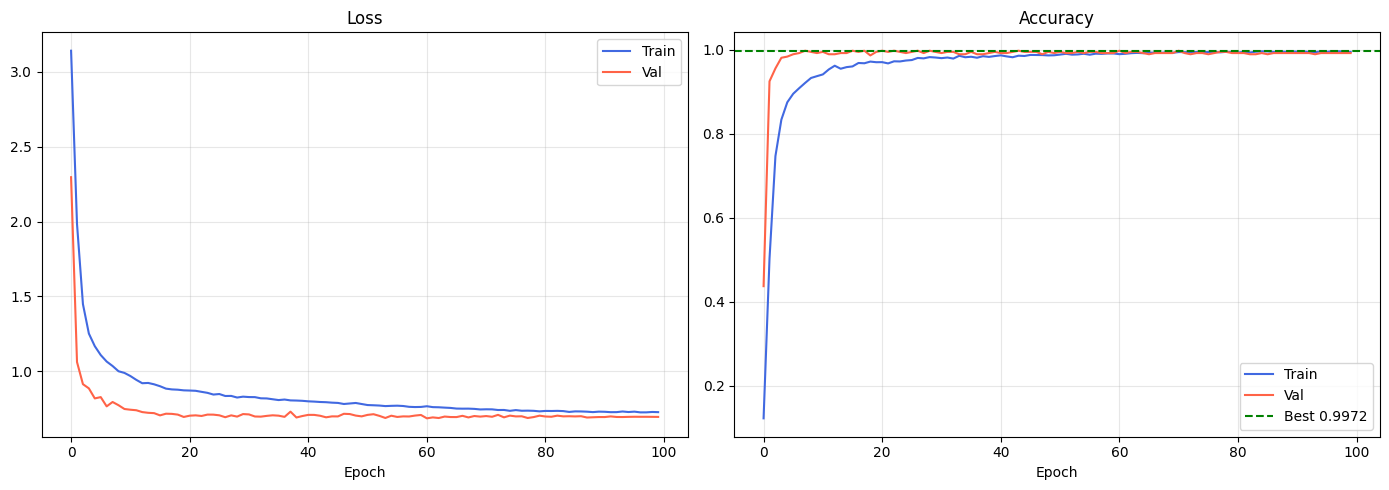


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00        12
           6       1.00      1.00      1.00        11
           7       1.00      1.00      1.00        15
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00        15
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        10
           C       1.00      1.00      1.00        11
           D       1.00      1.00      1.00         9
           E       1.00      1.00      1.00        10
           F       1.00      1.00      1.00        30
           G       1.00      1.00      1.00        17
   

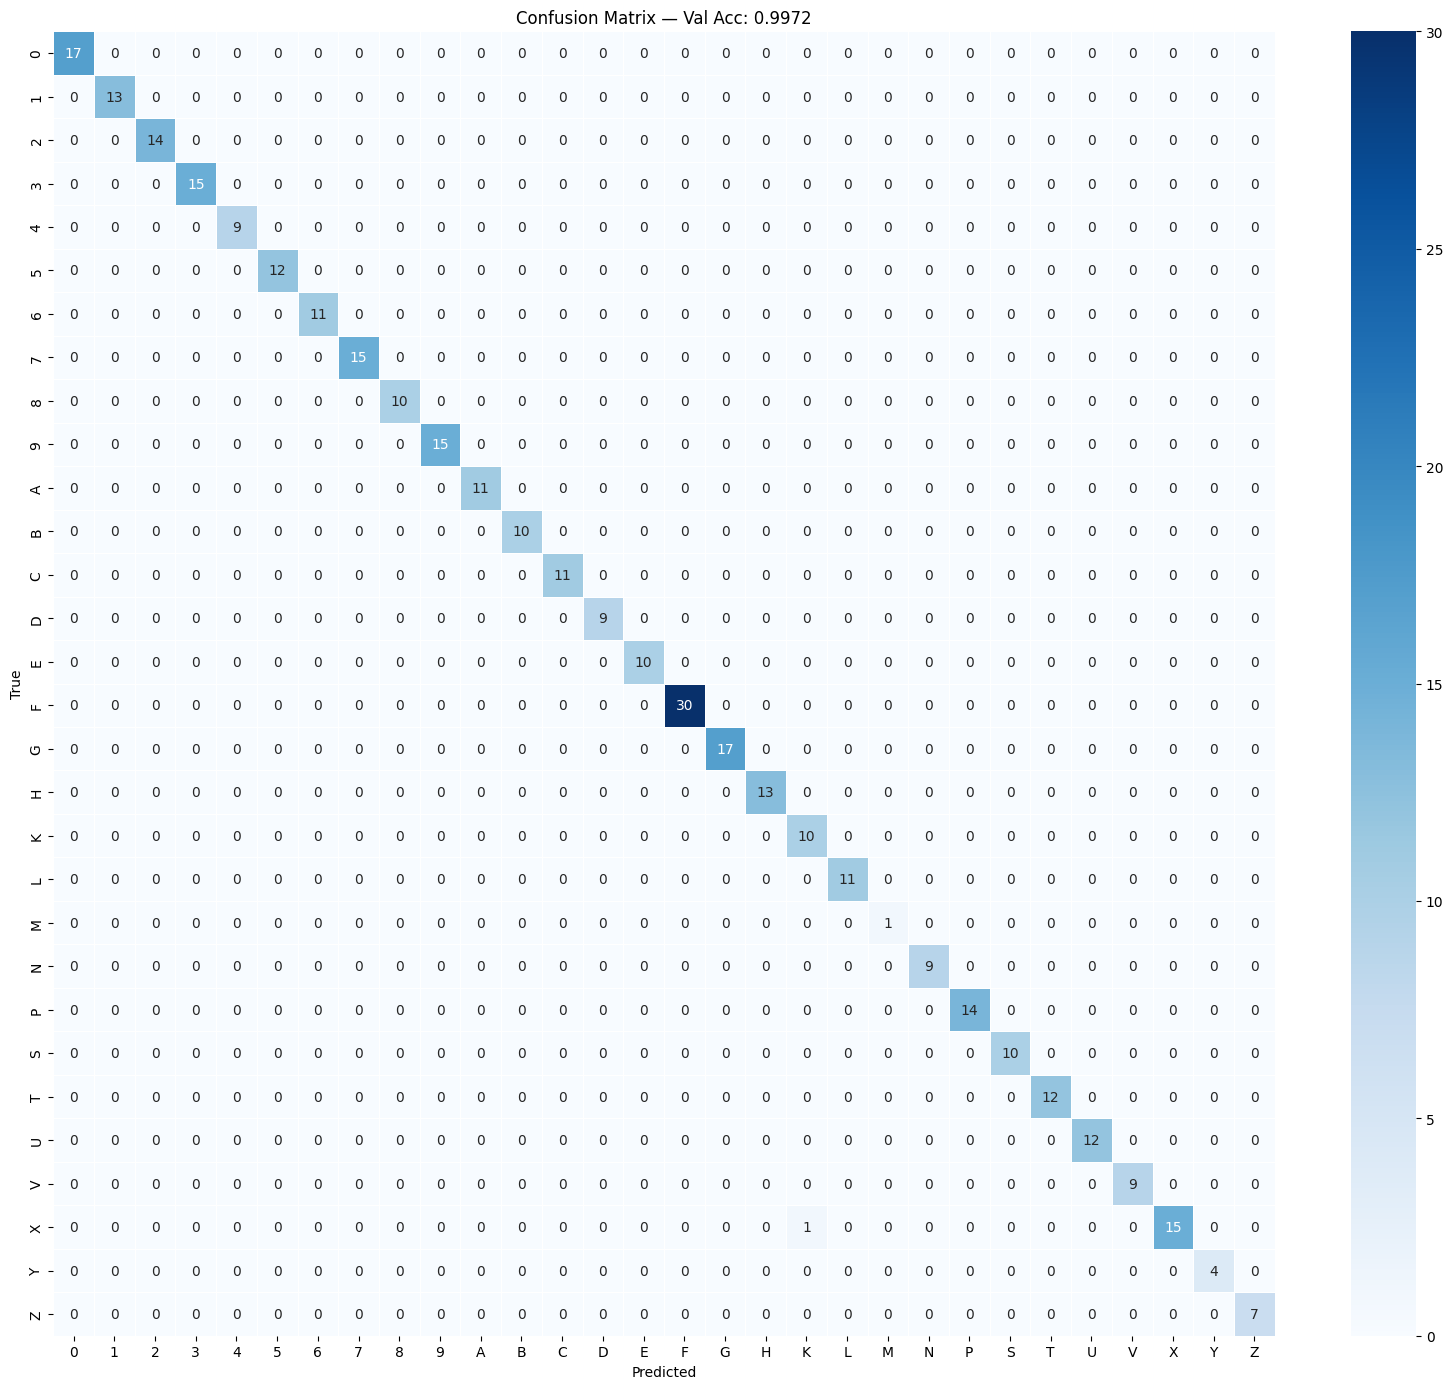

In [10]:
# ── 7. Plot training curves ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', color='royalblue')
ax1.plot(history['val_loss'],   label='Val',   color='tomato')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train', color='royalblue')
ax2.plot(history['val_acc'],   label='Val',   color='tomato')
ax2.axhline(best_acc, color='green', linestyle='--', label=f'Best {best_acc:.4f}')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

# ── 8. Đánh giá chi tiết trên val set ─────────────────────────────────
checkpoint = torch.load('/kaggle/working/best_char_cnn.pth')
model.load_state_dict(checkpoint['model_state'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes,
            cmap='Blues', linewidths=0.5)
plt.title(f'Confusion Matrix — Val Acc: {best_acc:.4f}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [11]:
def predict_char(img_path, model, classes, device=DEVICE):
    """Nhận diện 1 ký tự từ đường dẫn ảnh"""
    from PIL import Image
    tf = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    img    = tf(Image.open(img_path)).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(img)
        probs  = torch.softmax(logits, dim=1)
        top1   = probs.argmax(1).item()
    return classes[top1], probs[0][top1].item()